## khởi tạo môi trường:

In [1]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

import string
import warnings
warnings.filterwarnings('ignore')

SEED = 42

In [3]:
def concat_df(train_data, test_data):
    return pd.concat([train_data, test_data], sort=True).reset_index(drop=True)

def divide_df(all_data):
    return all_data.loc[:890], all_data.loc[891:].drop(['Survived'], axis=1)

df_train = pd.read_csv('/kaggle/input/titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/titanic/test.csv')

df_all = concat_df(df_train, df_test)

df_train.name = 'Training Set'
df_test.name = 'Test Set'
df_all.name = 'All Set'

dfs = [df_train, df_test]

print('Number of Training Examples = {}'.format(df_train.shape[0]))
print('Number of Test Examples = {}\n'.format(df_test.shape[0]))

print('Training X Shape = {}'.format(df_train.shape))
print('Training y Shape = {}\n'.format(df_train['Survived'].shape[0]))

print('Test X Shape = {}'.format(df_test.shape))
print('Test y Shape = {}\n'.format(df_test.shape[0]))

print(df_train.columns)
print(df_test.columns)

Number of Training Examples = 891
Number of Test Examples = 418

Training X Shape = (891, 12)
Training y Shape = 891

Test X Shape = (418, 11)
Test y Shape = 418

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


## Trích xuất đặc trưng

### 1 Phân nhóm giá trị liên tục

#### 1.1 Giá vé (Fare)
* Đặc trưng Fare có phân bố lệch phải (positively skewed), và tỷ lệ sống sót ở phía giá vé cao (phần đuôi bên phải) là rất lớn.
* Trong quá trình xử lý, 13 nhóm (bins) được tạo ra dựa trên phân vị (quantile-based bins) cho đặc trưng này. Mặc dù số lượng nhóm khá nhiều, nhưng chúng giúp mang lại lượng thông tin tăng thêm (information gain) đáng kể.
    * Các nhóm ở phía bên trái của biểu đồ (những hành khách có vé rẻ hơn) có tỷ lệ sống sót thấp nhất.
    * Các nhóm ở phía bên phải (vé đắt hơn) có tỷ lệ sống sót cao nhất.
* Điều đáng chú ý là tỷ lệ sống sót cao ở nhóm vé cao này không thể hiện rõ trong biểu đồ phân bố ban đầu, nhưng được phát hiện khi chia nhóm (binning).
* Ngoài ra, còn có một nhóm bất thường — khoảng (15.742, 23.25] — ở giữa biểu đồ có tỷ lệ sống sót cao bất ngờ, điều này chỉ được nhận ra nhờ quá trình phân nhóm.

In [26]:
df_all['Fare'] = pd.qcut(df_all['Fare'], 13)

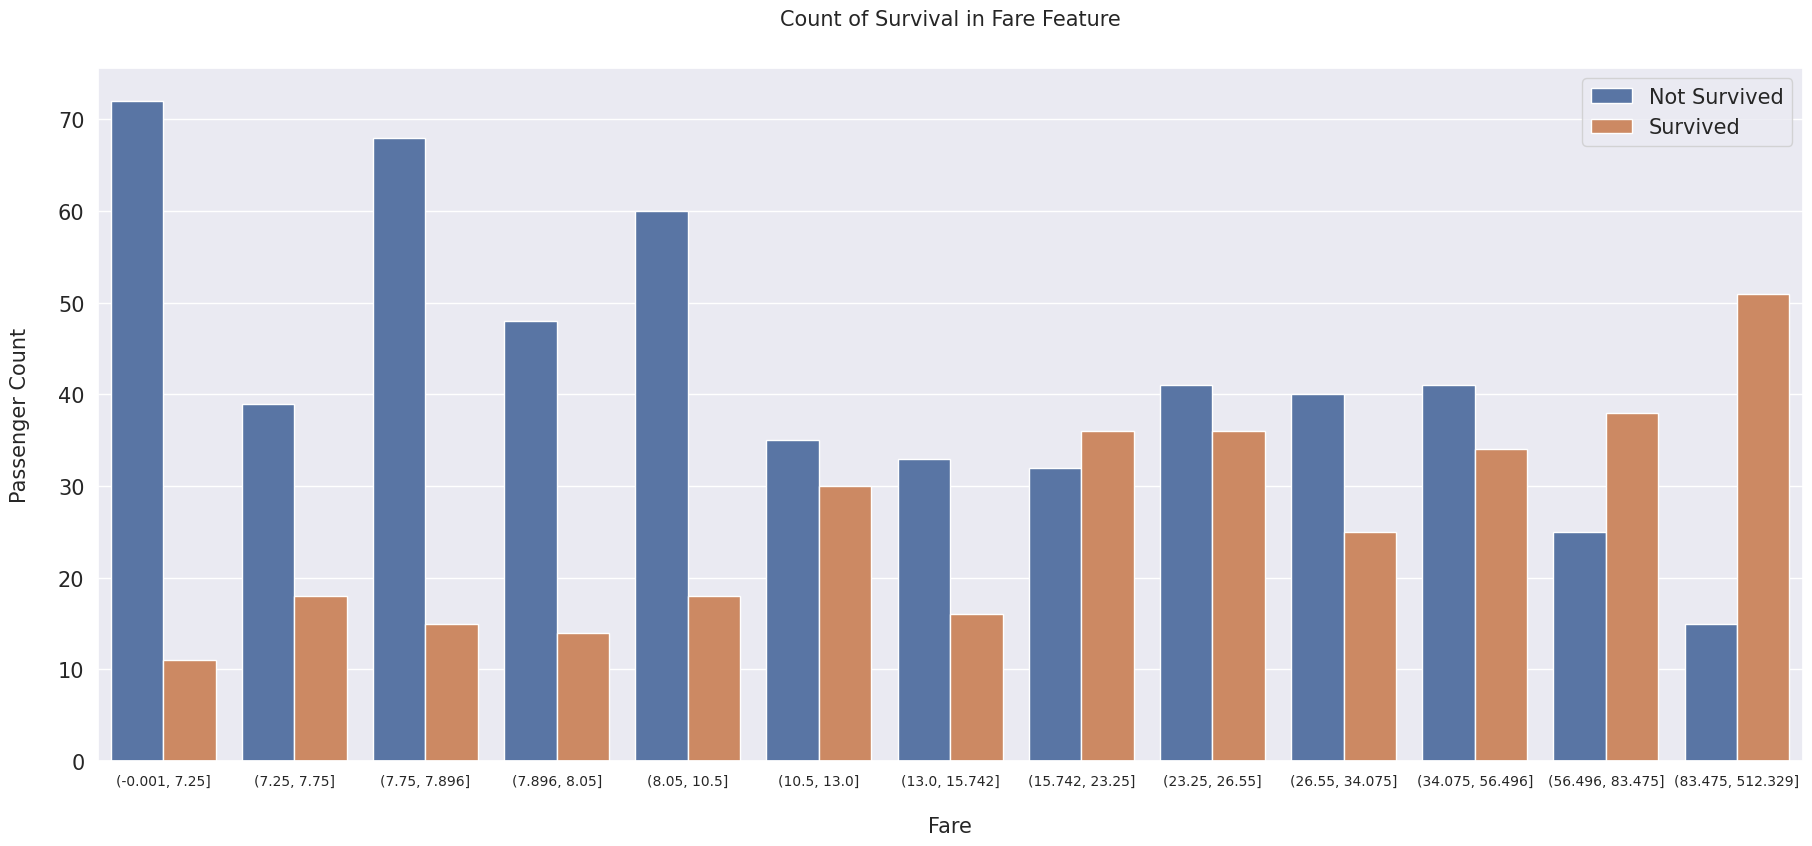

In [27]:
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Fare', hue='Survived', data=df_all)

plt.xlabel('Fare', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Count of Survival in {} Feature'.format('Fare'), size=15, y=1.05)

plt.show()

#### 1.2 Tuổi (Age)
* Đặc trưng Age có phân phối gần chuẩn (normal distribution) nhưng có một số điểm nhô lên và dao động nhỏ.
* Dữ liệu được chia thành 10 nhóm (bins) dựa trên phân vị (quantile) của tuổi.
    * Nhóm đầu tiên (những người trẻ nhất) có tỷ lệ sống sót cao nhất.
    * Nhóm thứ tư lại có tỷ lệ sống sót thấp nhất — đây là hai điểm nhô lớn nhất trong phân phối.
    * Ngoài ra còn có một nhóm tuổi bất thường (34.0, 40.0] với tỷ lệ sống sót cao, được thể hiện rõ trong quá trình này.

In [28]:
df_all['Age'] = pd.qcut(df_all['Age'], 10)

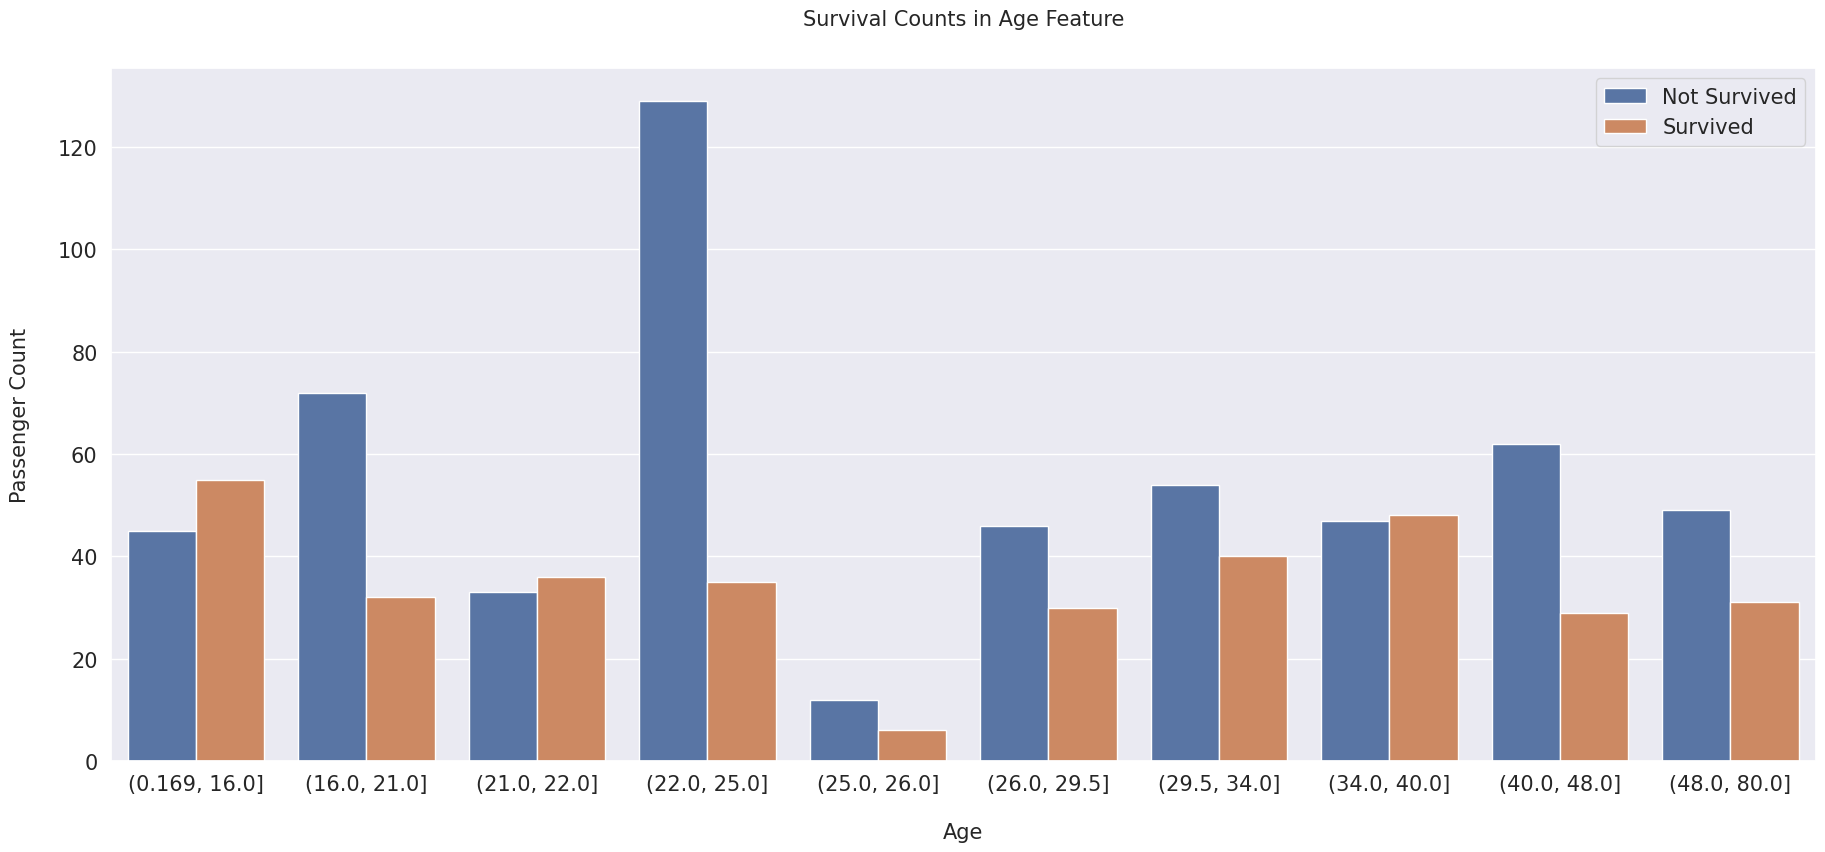

In [29]:
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Age', hue='Survived', data=df_all)

plt.xlabel('Age', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in {} Feature'.format('Age'), size=15, y=1.05)

plt.show()

### 2 Mã hoá tần xuất (Frequency Encoding)
* Family_Size được tạo ra bằng cách cộng ba giá trị: SibSp + Parch + 1
    * SibSp: số lượng anh/chị/em ruột và vợ/chồng đi cùng hành khách.
    * Parch: số lượng cha/mẹ và con cái đi cùng.
    * Cộng thêm 1 để tính chính hành khách đó.
* Việc tạo ra cột Family_Size giúp xác định quy mô gia đình, và các biểu đồ cho thấy kích thước gia đình là một yếu tố dự đoán tỷ lệ sống sót, vì các giá trị khác nhau dẫn đến tỷ lệ sống khác nhau.
* Phân loại theo kích thước gia đình:
    * Family Size = 1 → Gọi là Alone (đi một mình)
    * Family Size = 2, 3, 4 → Gọi là Small (nhỏ)
    * Family Size = 5, 6 → Gọi là Medium (trung bình)
    * Family Size = 7, 8, 11 → Gọi là Large (lớn)

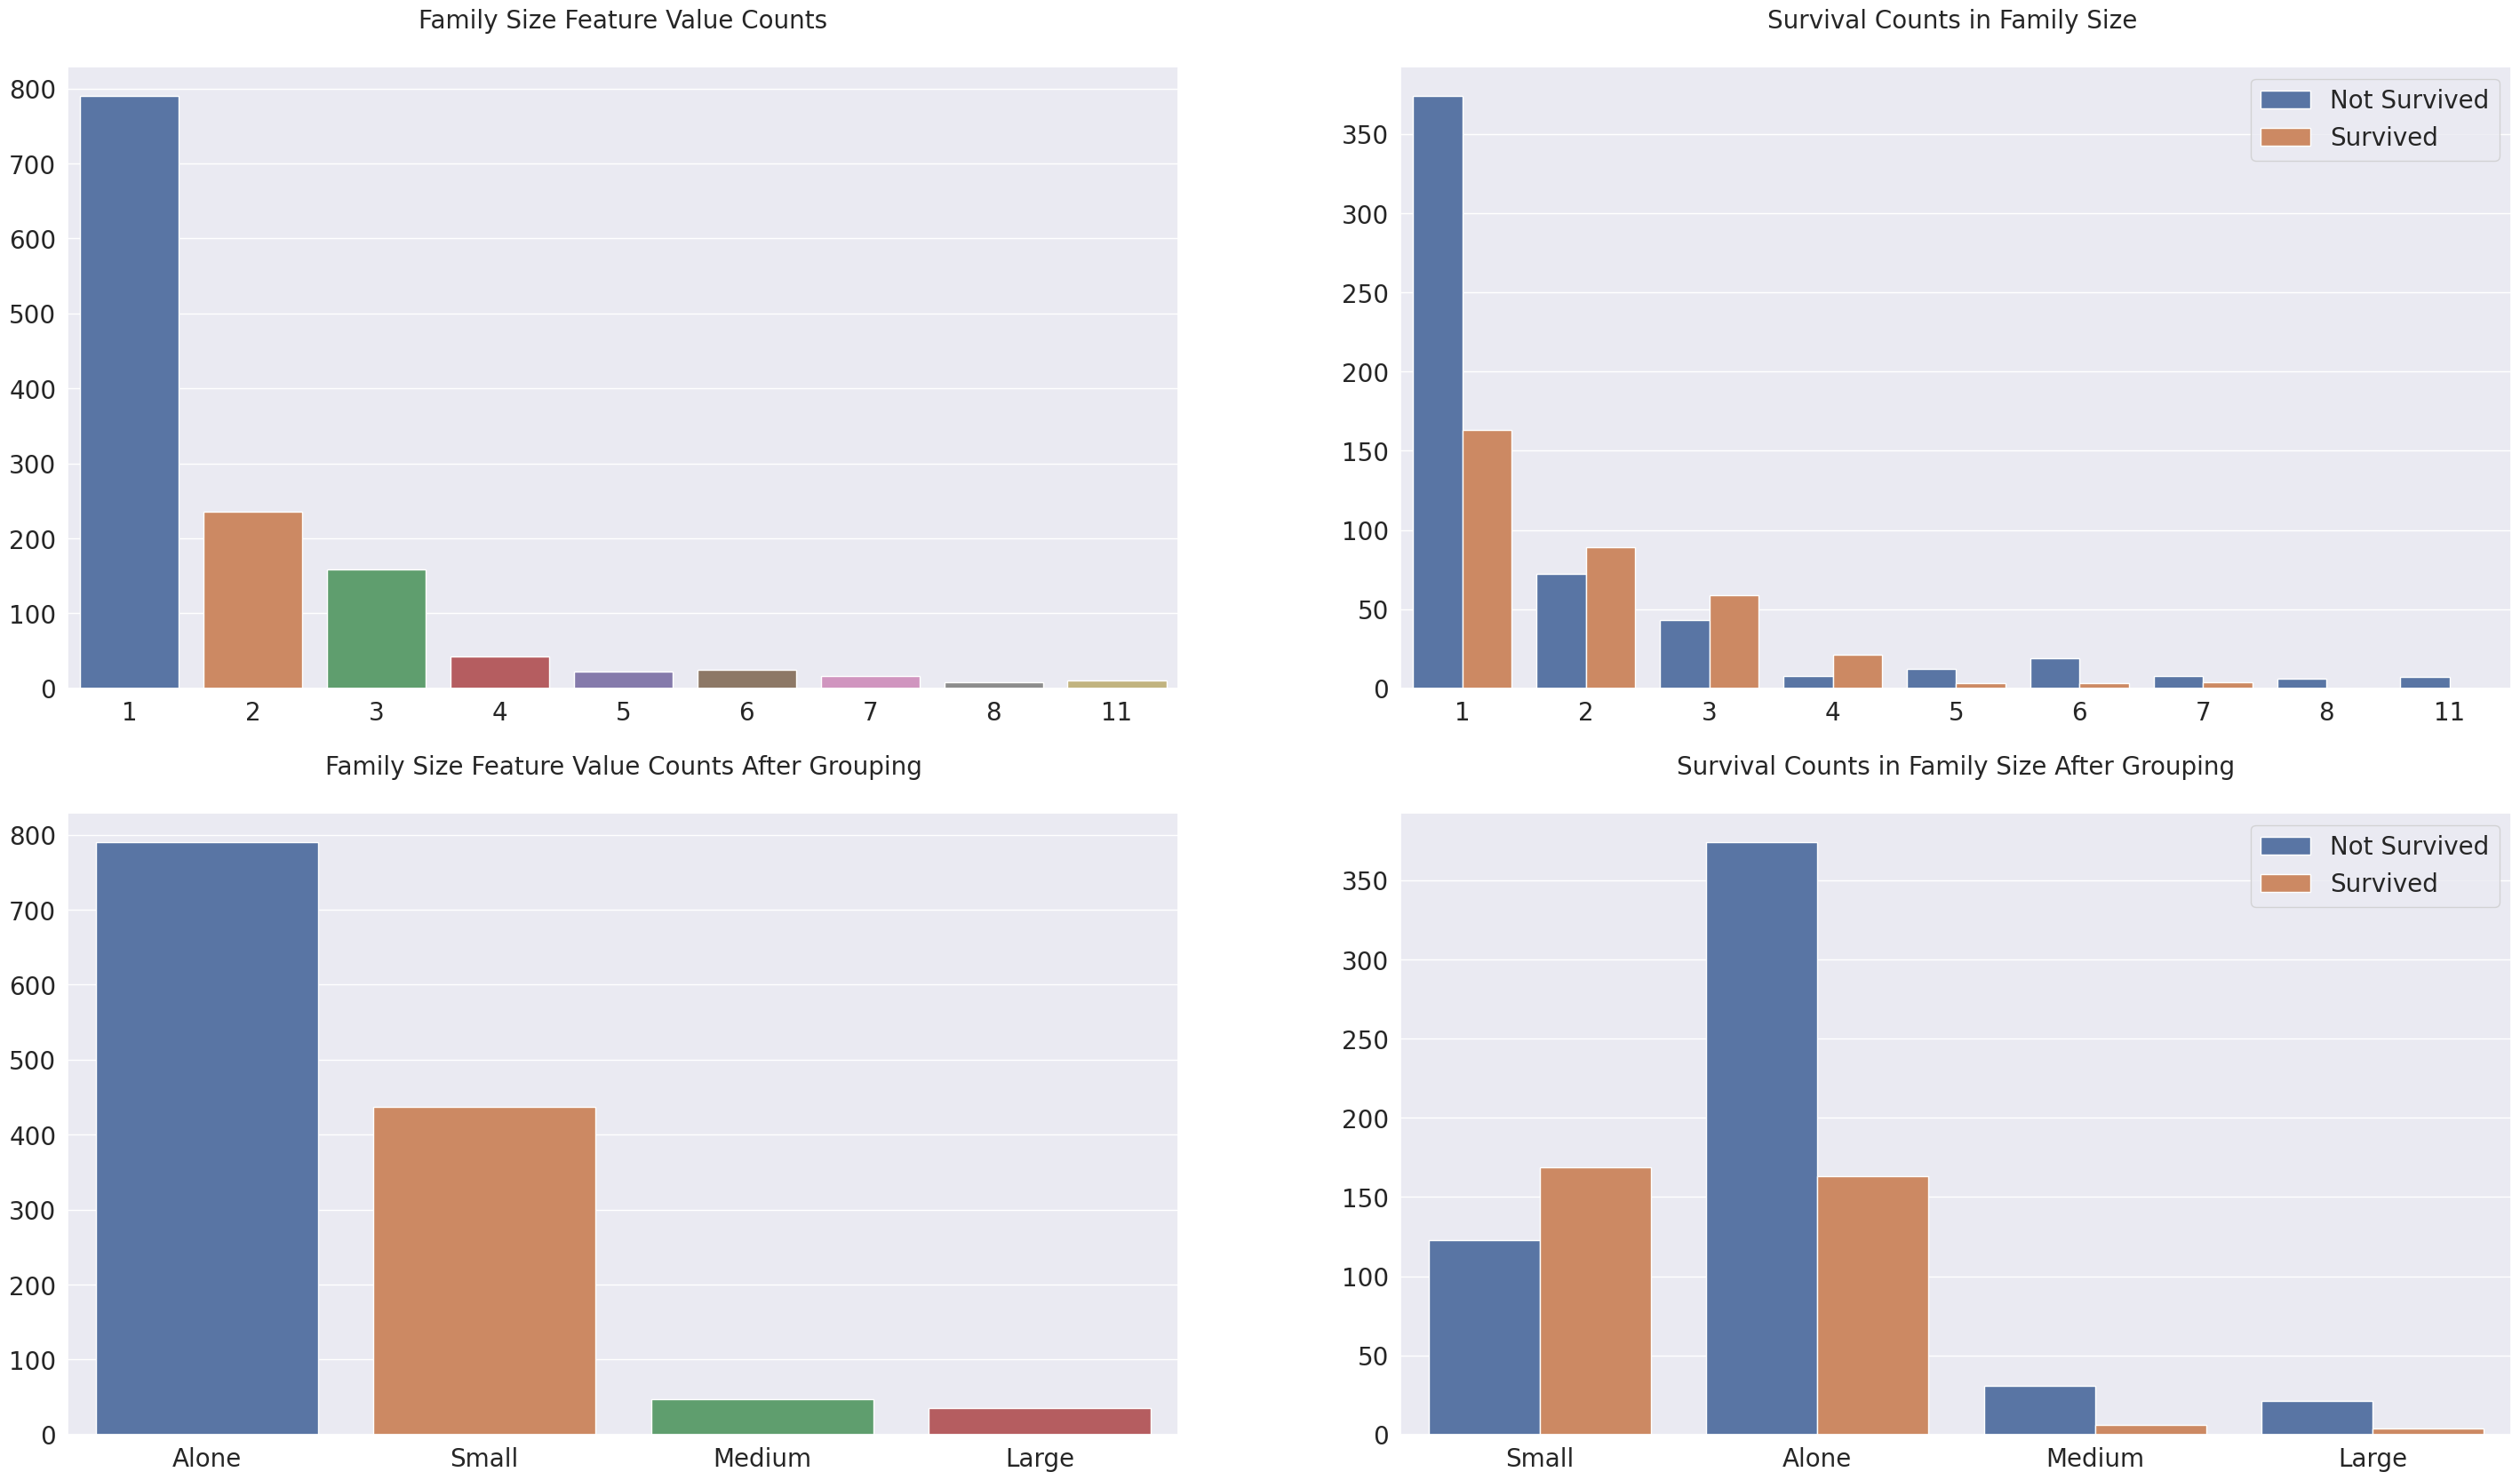

In [30]:
df_all['Family_Size'] = df_all['SibSp'] + df_all['Parch'] + 1

fig, axs = plt.subplots(figsize=(20, 20), ncols=2, nrows=2)
plt.subplots_adjust(right=1.5)

sns.barplot(x=df_all['Family_Size'].value_counts().index, y=df_all['Family_Size'].value_counts().values, ax=axs[0][0])
sns.countplot(x='Family_Size', hue='Survived', data=df_all, ax=axs[0][1])

axs[0][0].set_title('Family Size Feature Value Counts', size=20, y=1.05)
axs[0][1].set_title('Survival Counts in Family Size ', size=20, y=1.05)

family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
df_all['Family_Size_Grouped'] = df_all['Family_Size'].map(family_map)

sns.barplot(x=df_all['Family_Size_Grouped'].value_counts().index, y=df_all['Family_Size_Grouped'].value_counts().values, ax=axs[1][0])
sns.countplot(x='Family_Size_Grouped', hue='Survived', data=df_all, ax=axs[1][1])

axs[1][0].set_title('Family Size Feature Value Counts After Grouping', size=20, y=1.05)
axs[1][1].set_title('Survival Counts in Family Size After Grouping', size=20, y=1.05)

for i in range(2):
    axs[i][1].legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 20})
    for j in range(2):
        axs[i][j].tick_params(axis='x', labelsize=20)
        axs[i][j].tick_params(axis='y', labelsize=20)
        axs[i][j].set_xlabel('')
        axs[i][j].set_ylabel('')

plt.show()

Có quá nhiều giá trị Ticket (vé) khác nhau để phân tích riêng lẻ, vì vậy việc gom nhóm chúng theo tần suất xuất hiện sẽ giúp việc xử lý dễ dàng hơn. </br>

*Sự khác biệt giữa đặc trưng này và Family_Size là gì?* </br>

Nhiều hành khách không đi cùng gia đình mà đi theo nhóm – bao gồm bạn bè, bảo mẫu, người hầu, ... Những người này không được tính vào Family_Size, nhưng lại dùng chung một vé (Ticket). Tại sao không nhóm vé theo tiền tố (prefix)? </br>

Nếu tiền tố trong cột Ticket mang ý nghĩa (ví dụ thể hiện hạng vé hay điểm khởi hành), thì thông tin đó đã được phản ánh trong các cột Pclass hoặc Embarked. Do đó, việc nhóm theo tiền tố sẽ không mang thêm thông tin mới. </br>

Kết quả quan sát từ biểu đồ:
* Nhóm có 2, 3 hoặc 4 người dùng chung vé → có tỷ lệ sống sót cao hơn.
* Hành khách đi một mình → có tỷ lệ sống sót thấp nhất.
* Sau 4 người, tỷ lệ sống giảm mạnh.

Mẫu này rất giống với đặc trưng Family_Size, nhưng vẫn có một số khác biệt nhỏ. </br>
Tuy nhiên, Ticket_Frequency không được chia nhóm giống Family_Size, vì làm vậy sẽ tạo ra một biến gần như trùng khớp (tương quan hoàn hảo), và sẽ không mang lại thêm thông tin hữu ích cho mô hình.

In [31]:
df_all['Ticket_Frequency'] = df_all.groupby('Ticket')['Ticket'].transform('count')

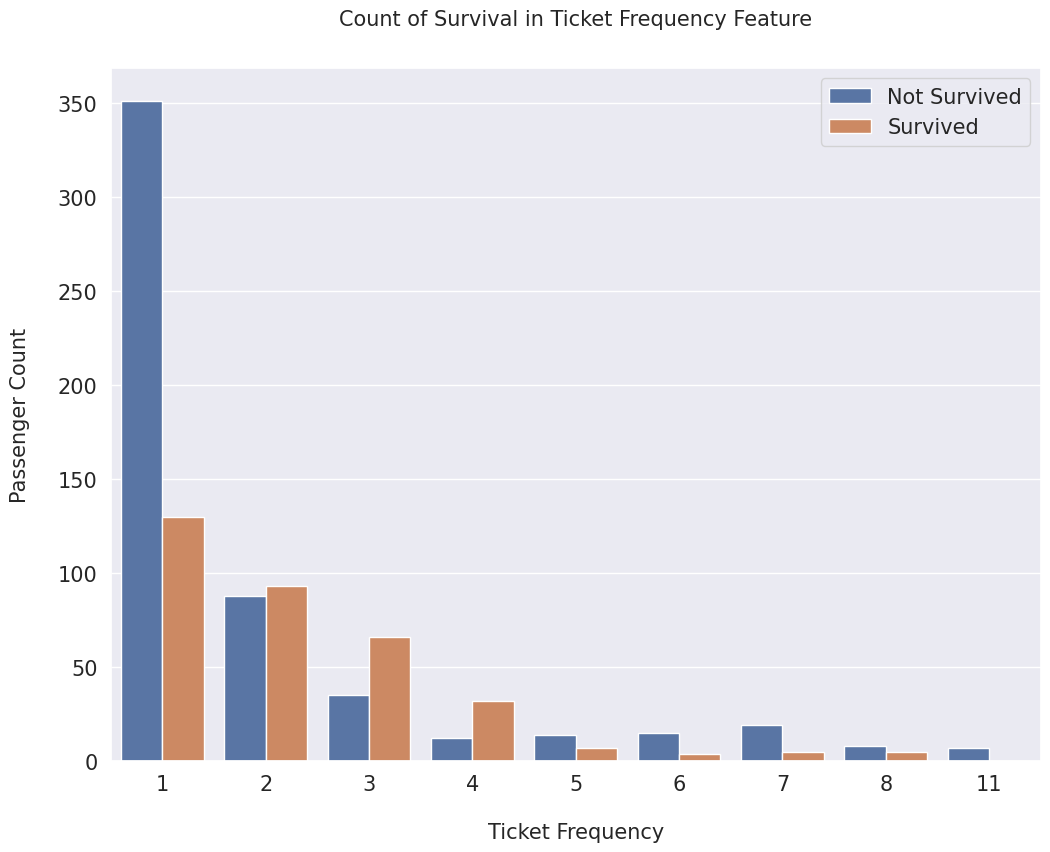

In [32]:
fig, axs = plt.subplots(figsize=(12, 9))
sns.countplot(x='Ticket_Frequency', hue='Survived', data=df_all)

plt.xlabel('Ticket Frequency', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Count of Survival in {} Feature'.format('Ticket Frequency'), size=15, y=1.05)

plt.show()

### 3 Danh xưng và tình trạng kết hôn (Title & Is Married)

'Title' (Danh xưng) được tạo ra bằng cách tách phần tiền tố trước cột Name (Tên) của hành khách.
Theo biểu đồ bên dưới, có rất nhiều danh xưng chỉ xuất hiện rất ít lần. Một số danh xưng không chính xác và cần được chuẩn hoá hoặc thay thế.

* Chuẩn hoá danh xưng: Miss, Mrs, Ms, Mlle, Lady, Mme, the Countess, Dona → được gộp lại thành nhóm Miss/Mrs/Ms, vì tất cả đều là nữ giới. </br>

  *Lưu ý: Mlle, Mme và Dona thực ra là tên riêng của hành khách, nhưng lại bị nhận diện nhầm thành danh xưng vì cột Name được tách theo dấu phẩy.* </br>

    * Dr, Col, Major, Jonkheer, Capt, Sir, Don, Rev → được thay thế thành các nhóm chung: Dr / Military / Noble / Clergy, vì họ có đặc điểm xã hội tương đồng (bác sĩ, quân nhân, quý tộc, tu sĩ). </br>

    * Master là một danh xưng đặc biệt, chỉ dùng cho nam giới dưới 26 tuổi, và họ có tỷ lệ sống sót cao nhất trong tất cả các nam hành khách. </br>

* Biến Is_Married:

    * Đây là biến nhị phân (binary) được tạo ra dựa trên danh xưng "Mrs". Danh xưng Mrs có tỷ lệ sống sót cao nhất trong các danh xưng nữ. Do tất cả các danh xưng nữ đều đã được nhóm chung lại, nên việc tách riêng Mrs thành biến Is_Married giúp mô hình phân biệt rõ hơn giữa phụ nữ đã kết hôn và chưa kết hôn.

In [33]:
df_all['Title'] = df_all['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
df_all['Is_Married'] = 0
df_all['Is_Married'].loc[df_all['Title'] == 'Mrs'] = 1

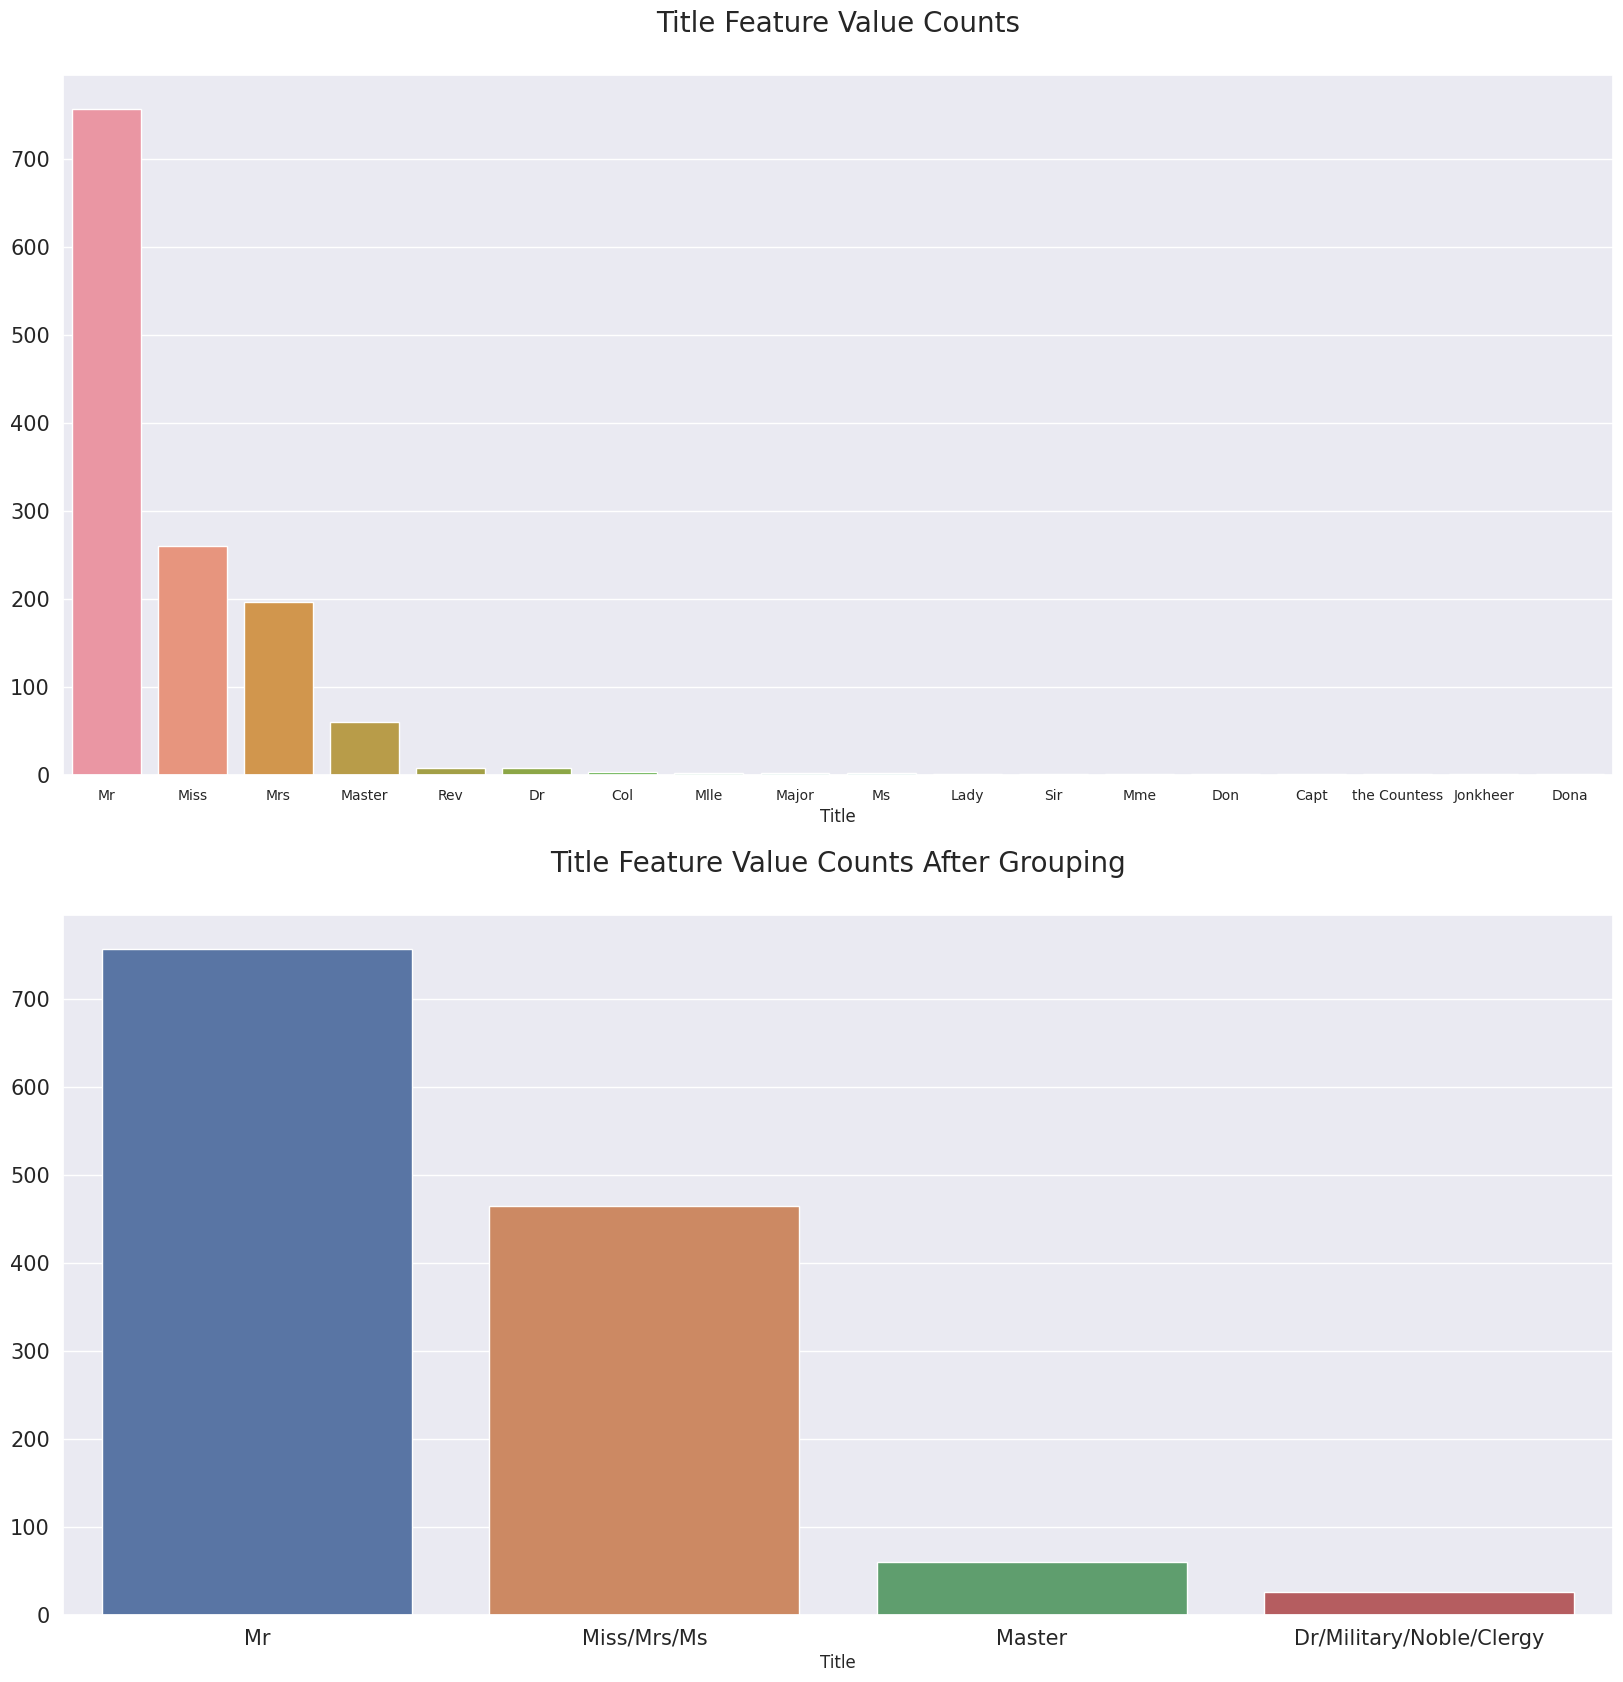

In [34]:
fig, axs = plt.subplots(nrows=2, figsize=(20, 20))
sns.barplot(x=df_all['Title'].value_counts().index, y=df_all['Title'].value_counts().values, ax=axs[0])

axs[0].tick_params(axis='x', labelsize=10)
axs[1].tick_params(axis='x', labelsize=15)

for i in range(2):    
    axs[i].tick_params(axis='y', labelsize=15)

axs[0].set_title('Title Feature Value Counts', size=20, y=1.05)

df_all['Title'] = df_all['Title'].replace(['Miss', 'Mrs','Ms', 'Mlle', 'Lady', 'Mme', 'the Countess', 'Dona'], 'Miss/Mrs/Ms')
df_all['Title'] = df_all['Title'].replace(['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'], 'Dr/Military/Noble/Clergy')

sns.barplot(x=df_all['Title'].value_counts().index, y=df_all['Title'].value_counts().values, ax=axs[1])
axs[1].set_title('Title Feature Value Counts After Grouping', size=20, y=1.05)

plt.show()

### 4 Mã hoá mục tiêu (Target Encoding)

Hàm **extract_surname** được sử dụng để trích xuất họ (surname) của hành khách từ cột Name. </br>
Sau đó, một biến mới có tên là Family được tạo ra từ họ đã trích xuất — mục đích là nhóm các hành khách thuộc cùng một gia đình lại với nhau.

In [35]:
def extract_surname(data):    
    
    families = []
    
    for i in range(len(data)):        
        name = data.iloc[i]

        if '(' in name:
            name_no_bracket = name.split('(')[0] 
        else:
            name_no_bracket = name
            
        family = name_no_bracket.split(',')[0]
        title = name_no_bracket.split(',')[1].strip().split(' ')[0]
        
        for c in string.punctuation:
            family = family.replace(c, '').strip()
            
        families.append(family)
            
    return families

df_all['Family'] = extract_surname(df_all['Name'])
df_train = df_all.loc[:890]
df_test = df_all.loc[891:]
dfs = [df_train, df_test]

In [36]:
mean_survival_rate = df_train['Survived'].mean()
non_unique_families = set(df_train['Family']).intersection(set(df_test['Family']))

family_counts = df_train['Family'].value_counts()

valid_families = [f for f in non_unique_families if family_counts.get(f, 0) > 1]

family_rates_series = df_train.groupby('Family')['Survived'].mean()

family_rates = family_rates_series[family_rates_series.index.isin(valid_families)].to_dict()

df_train['Family_Survival_Rate'] = df_train['Family'].map(family_rates).fillna(mean_survival_rate)
df_train['Family_Survival_Rate_NA'] = df_train['Family'].isin(family_rates).astype(int)

df_test['Family_Survival_Rate'] = df_test['Family'].map(family_rates).fillna(mean_survival_rate)
df_test['Family_Survival_Rate_NA'] = df_test['Family'].isin(family_rates).astype(int)

# Tương tự cho ticket
non_unique_tickets = set(df_train['Ticket']).intersection(set(df_test['Ticket']))
ticket_counts = df_train['Ticket'].value_counts()
valid_tickets = [t for t in non_unique_tickets if ticket_counts.get(t, 0) > 1]

ticket_rates_series = df_train.groupby('Ticket')['Survived'].mean()
ticket_rates = ticket_rates_series[ticket_rates_series.index.isin(valid_tickets)].to_dict()

df_train['Ticket_Survival_Rate'] = df_train['Ticket'].map(ticket_rates).fillna(mean_survival_rate)
df_train['Ticket_Survival_Rate_NA'] = df_train['Ticket'].isin(ticket_rates).astype(int)

df_test['Ticket_Survival_Rate'] = df_test['Ticket'].map(ticket_rates).fillna(mean_survival_rate)
df_test['Ticket_Survival_Rate_NA'] = df_test['Ticket'].isin(ticket_rates).astype(int)


In [37]:
for df in [df_train, df_test]:
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2  

### 5 Biến đổi đặc trưng (Feature Transformation)

#### 5.1 Mã hóa nhãn (Label Encoding) cho các đặc trưng không phải số

Các đặc trưng **Embarked**, **Sex**, **Deck**, **Title** và **Family_Size_Grouped** thuộc kiểu đối tượng (object), còn các đặc trưng **Age** và **Fare** thuộc kiểu phân loại (category). Chúng được chuyển đổi sang kiểu số bằng LabelEncoder. </br>
LabelEncoder cơ bản sẽ gán nhãn cho các lớp từ 0 đến n. Quá trình này là cần thiết để các mô hình có thể học từ những đặc trưng này.

In [38]:
non_numeric_features = ['Embarked', 'Sex', 'Deck', 'Title', 'Family_Size_Grouped', 'Age', 'Fare']

for df in dfs:
    for feature in non_numeric_features:        
        df[feature] = LabelEncoder().fit_transform(df[feature])

#### 5.2 Mã hóa One-Hot cho các đặc trưng phân loại

* Các đặc trưng phân loại (Pclass, Sex, Deck, Embarked, Title) được chuyển thành các đặc trưng one-hot bằng OneHotEncoder.
* Các đặc trưng Age và Fare không được chuyển đổi vì chúng là thuộc thứ tự (ordinal), khác với các đặc trưng phân loại ở trên.

In [39]:
cat_features = ['Pclass', 'Sex', 'Deck', 'Embarked', 'Title', 'Family_Size_Grouped']
encoded_features = []

for df in dfs:
    for feature in cat_features:
        encoded_feat = OneHotEncoder().fit_transform(df[feature].values.reshape(-1, 1)).toarray()
        n = df[feature].nunique()
        cols = ['{}_{}'.format(feature, n) for n in range(1, n + 1)]
        encoded_df = pd.DataFrame(encoded_feat, columns=cols)
        encoded_df.index = df.index
        encoded_features.append(encoded_df)

df_train = pd.concat([df_train, *encoded_features[:6]], axis=1)
df_test = pd.concat([df_test, *encoded_features[6:]], axis=1)

### 6 Kết luận

Các đặc trưng Age và Fare đã được phân nhóm (binned). Việc phân nhóm giúp xử lý các giá trị ngoại lai (outliers) và cũng làm lộ ra một số nhóm đồng nhất trong các đặc trưng này. </br>
Family_Size được tạo ra bằng cách cộng các đặc trưng Parch và SibSp với 1. Ticket_Frequency được tạo bằng cách đếm số lần xuất hiện của các giá trị Ticket. </br>
Đặc trưng Name rất hữu ích. </br>
* Thứ nhất, các đặc trưng Title và Is_Married được tạo từ tiền tố danh xưng trong tên.
* Thứ hai, các đặc trưng Family_Survival_Rate và Family_Survival_Rate_NA được tạo bằng mã hóa theo mục tiêu (target encoding) dựa trên họ của hành khách. Ticket_Survival_Rate được tạo bằng cách target encoding trên đặc trưng Ticket. Survival_Rate được tạo bằng cách lấy trung bình của Family_Survival_Rate và Ticket_Survival_Rate.

Cuối cùng, các đặc trưng không phải số được mã hóa nhãn (label encoded) và các đặc trưng phân loại được one-hot encoded. 5 đặc trưng mới được tạo ra gồm: Family_Size, Title, Is_Married, Survival_Rate và Survival_Rate_NA, đồng thời các đặc trưng không hữu ích đã bị loại bỏ sau khi mã hóa.

In [40]:
df_all = concat_df(df_train, df_test)
drop_cols = ['Deck', 'Embarked', 'Family', 'Family_Size', 'Family_Size_Grouped', 'Survived',
             'Name', 'Parch', 'PassengerId', 'Pclass', 'Sex', 'SibSp', 'Ticket', 'Title',
            'Ticket_Survival_Rate', 'Family_Survival_Rate', 'Ticket_Survival_Rate_NA', 'Family_Survival_Rate_NA']

df_all.drop(columns=drop_cols, inplace=True)

df_all.head()

,Age,Deck_1,Deck_2,Deck_3,Deck_4,Embarked_1,Embarked_2,Embarked_3,Family_Size_Grouped_1,Family_Size_Grouped_2,...,Pclass_3,Sex_1,Sex_2,Survival_Rate,Survival_Rate_NA,Ticket_Frequency,Title_1,Title_2,Title_3,Title_4
0,2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.383838,0.0,1,0.0,0.0,0.0,1.0
1,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.383838,0.0,2,0.0,0.0,1.0,0.0
2,4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.383838,0.0,1,0.0,0.0,1.0,0.0
3,7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.383838,0.0,2,0.0,0.0,1.0,0.0
4,7,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.383838,0.0,1,0.0,0.0,0.0,1.0


## Kết thúc

In [1]:
!jupyter nbconvert --to html "processing.ipynb"

[NbConvertApp] Converting notebook processing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 853142 bytes to processing.html
